In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from new_module.dev_utils.utils import *

In [15]:
def read_outputs(file_path, loss_list = []):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    # outputs['generations'] = outputs['generations'].apply(lambda x: [x])
    outputs['prompt']=outputs['prompt'].apply(lambda x: x['text'])
    
    # outputs['text']=outputs['generations'].apply(lambda x: x['text'])
    
    gen_keys = [set(x.keys()) for x in outputs['generations'].values]
    gen_key = set()
    for gen_key_i in gen_keys:
        gen_key |= gen_key_i
    
    for col in gen_key:
        outputs[col] = outputs['generations'].apply(lambda x: x.get(col,None))
    
    for i in range(len(outputs['losses'][0])):
        outputs[loss_list[i]] = outputs['losses'].apply(lambda x: x[i])
        
    outputs.drop(columns=['generations'],inplace=True)
    return outputs

In [16]:
paths = {
    'log_scale' : 'outputs/sentiment/positive_gpt2/svodcpjl/outputs_epsilon0.97.txt',
    'proba_scale' : 'outputs/sentiment/positive_gpt2/f8pvcd98/outputs_epsilon0.97.txt',
    'mix_scale' : 'outputs/sentiment/positive_gpt2/mqceg9du/outputs_epsilon0.97.txt',
}

jsons = {
    'log_scale' : read_outputs(paths['log_scale'], loss_list = ['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']),
    'proba_scale' : read_outputs(paths['proba_scale'], loss_list = ['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']),
    'mix_scale' : read_outputs(paths['mix_scale'], loss_list = ['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']),
}

In [37]:
# Select only the energy columns
energy_cols = ['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']

# Apply weight to the column values
loss_weights = [1, 1, 1, 1]
weighted_data = jsons['log_scale'][energy_cols].mul(loss_weights, axis=1)


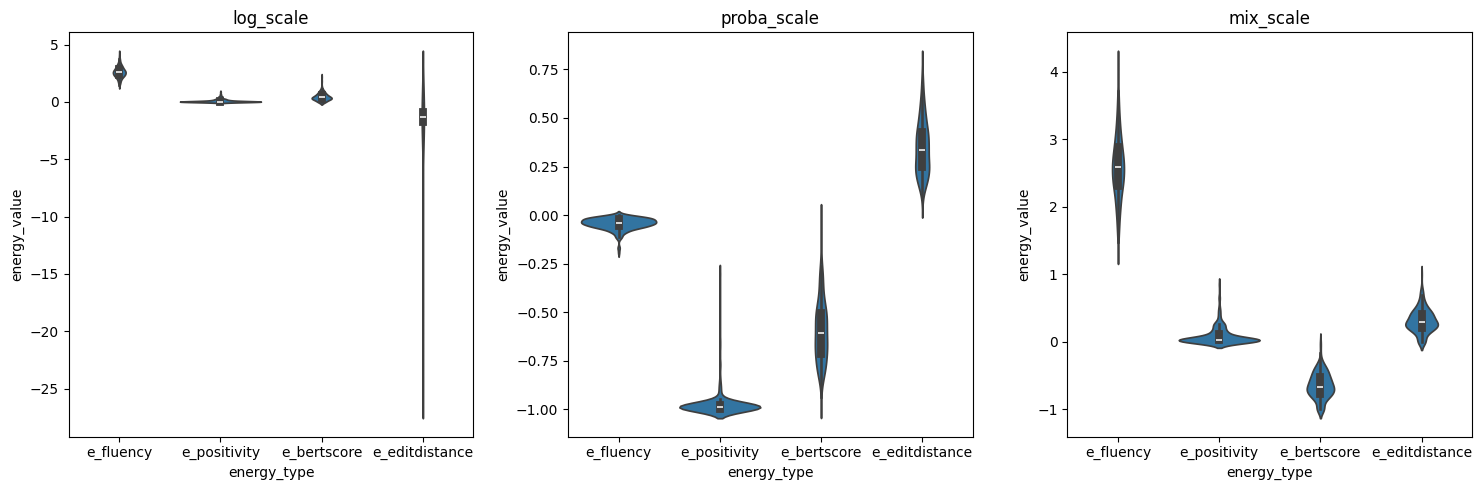

In [57]:
# Variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5) )
loss_weights = [1, 1, 1, 1]
scales = ['log_scale', 'proba_scale', 'mix_scale']

# Select only the energy columns
energy_cols = ['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']

for scale, ax in zip(scales, axes):

    
    # Apply weight to the column values
    weighted_data = jsons[scale][energy_cols].mul(loss_weights, axis=1)

    # # Min-Max Normalization
    # for col in energy_cols:
    #     x_min = jsons[scale][col].min()
    #     x_max = jsons[scale][col].max()
    #     weighted_data[col] = jsons[scale][col].apply(lambda x: (x - x_min) / (x_max - x_min))

    # Melt the data from wide to long format
    melted_data = pd.melt(weighted_data, 
                        value_vars=energy_cols,
                        var_name='energy_type',  # Name for the new categorical column
                        value_name='energy_value')  # Name for the new value column

    #  Turn energy value to absolute value
    # melted_data['energy_value'] = melted_data['energy_value'].abs()

    # Now you can create violin plots
    sns.violinplot(data=melted_data, x='energy_type', y='energy_value', ax=ax)
    # sns.boxplot(data=melted_data, x='energy_type', y='energy_value', ax=ax)
    # ax.set_ylabel('Absolute Value of Energy')
    ax.set_title(scale)
plt.tight_layout()


In [ ]:
sns.boxplot()

In [ ]:
## 보고 싶은거는 violin plot인데, 
## x 에 loss 1,2,3,4 가 써있으면 좋겠고, y는 그 값이었으면 좋겠음

## 그리고 각 x를 어떻게 scale하느냐에 따라서 box plot을 새로 그릴 수 있으면 좋겠음. 

In [33]:
jsons['log_scale'][['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']].describe().round(3).loc[['mean', 'min', 'max'], :]

,e_fluency,e_positivity,e_bertscore,e_editdistance
mean,2.619,0.094,0.454,-3.419
min,1.505,0.000,-0.000,-23.026
max,4.137,0.880,2.196,-0.087


In [35]:
jsons['mix_scale'][['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']].describe().round(3).loc[['mean', 'min', 'max'], :]

,e_fluency,e_positivity,e_bertscore,e_editdistance
mean,2.587,0.088,-0.646,0.315
min,1.473,0.000,-1.000,0.000
max,3.994,0.849,-0.010,1.000


In [ ]:
# Reshape data for violin plots
energy_cols = ['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']

# Melt the data from wide to long format
melted_data = pd.melt(jsons['log_scale'], 
                      value_vars=energy_cols,
                      var_name='energy_type',
                      value_name='energy_value')

# Create violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=melted_data, x='energy_type', y='energy_value')
plt.title('Energy Distribution by Type')
plt.xlabel('Energy Type')
plt.ylabel('Energy Value')
plt.xticks(rotation=45)
plt.tight_layout()


In [34]:
jsons['proba_scale'][['e_fluency', 'e_positivity', 'e_bertscore', 'e_editdistance']].describe().round(3).loc[['mean', 'min', 'max'], :]

,e_fluency,e_positivity,e_bertscore,e_editdistance
mean,-0.044,-0.974,-0.594,0.350
min,-0.193,-1.000,-0.935,0.083
max,-0.001,-0.302,-0.053,0.750


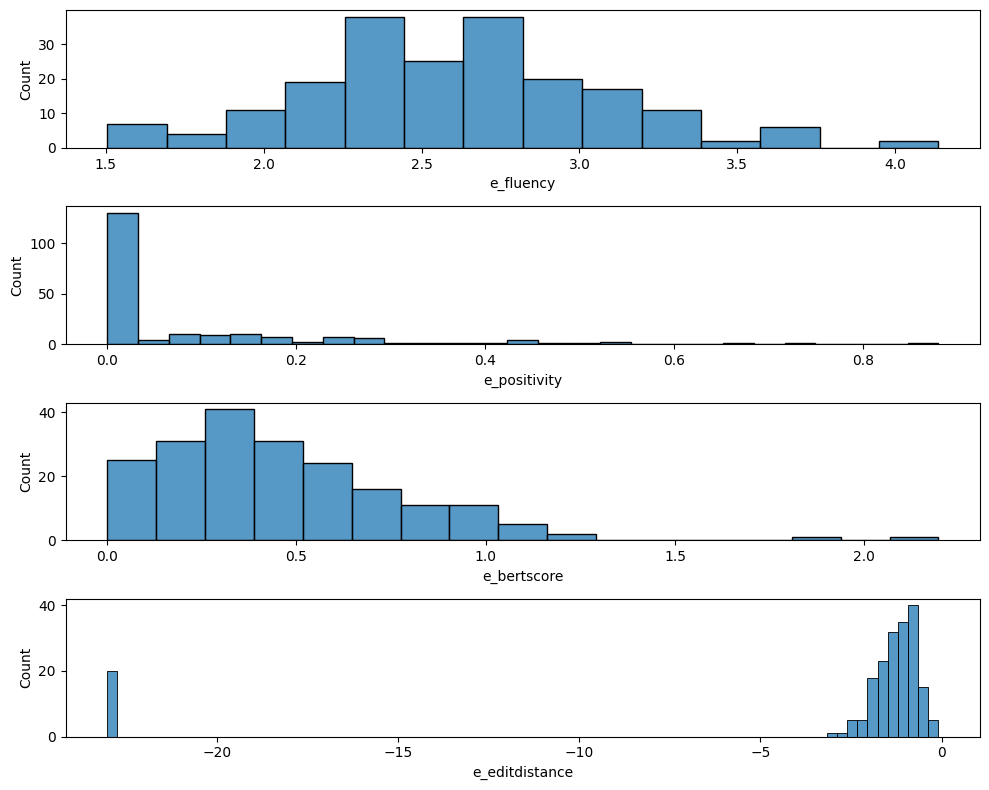

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8))
sns.histplot(data=jsons['log_scale'], 
             x='e_fluency',
             ax=axes[0])
axes[0].set_xlabel('e_fluency')

sns.histplot(data=jsons['log_scale'], 
             x='e_positivity',
             ax=axes[1])
axes[1].set_xlabel('e_positivity')

sns.histplot(data=jsons['log_scale'], 
             x='e_bertscore',
             ax=axes[2])
axes[2].set_xlabel('e_bertscore')

sns.histplot(data=jsons['log_scale'], 
             x='e_editdistance',
             ax=axes[3])
axes[3].set_xlabel('e_editdistance')

plt.tight_layout()

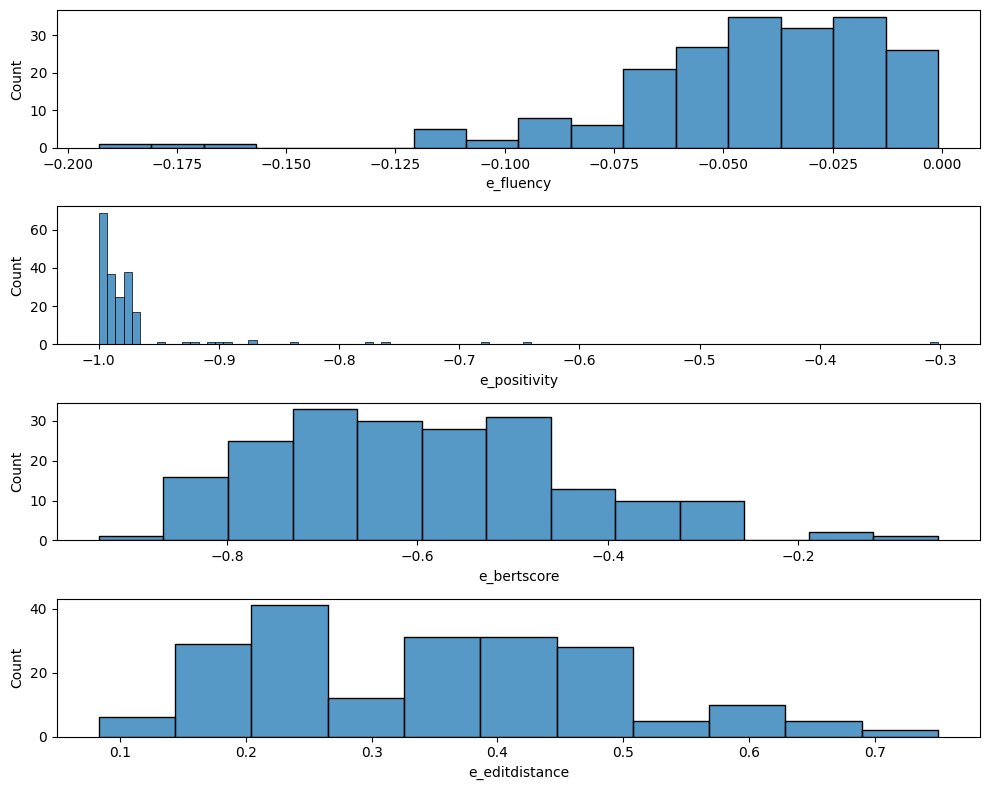

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8))
sns.histplot(data=jsons['proba_scale'], 
             x='e_fluency',
             ax=axes[0])
axes[0].set_xlabel('e_fluency')

sns.histplot(data=jsons['proba_scale'], 
             x='e_positivity',
             ax=axes[1])
axes[1].set_xlabel('e_positivity')

sns.histplot(data=jsons['proba_scale'], 
             x='e_bertscore',
             ax=axes[2])
axes[2].set_xlabel('e_bertscore')

sns.histplot(data=jsons['proba_scale'], 
             x='e_editdistance',
             ax=axes[3])
axes[3].set_xlabel('e_editdistance')

plt.tight_layout()

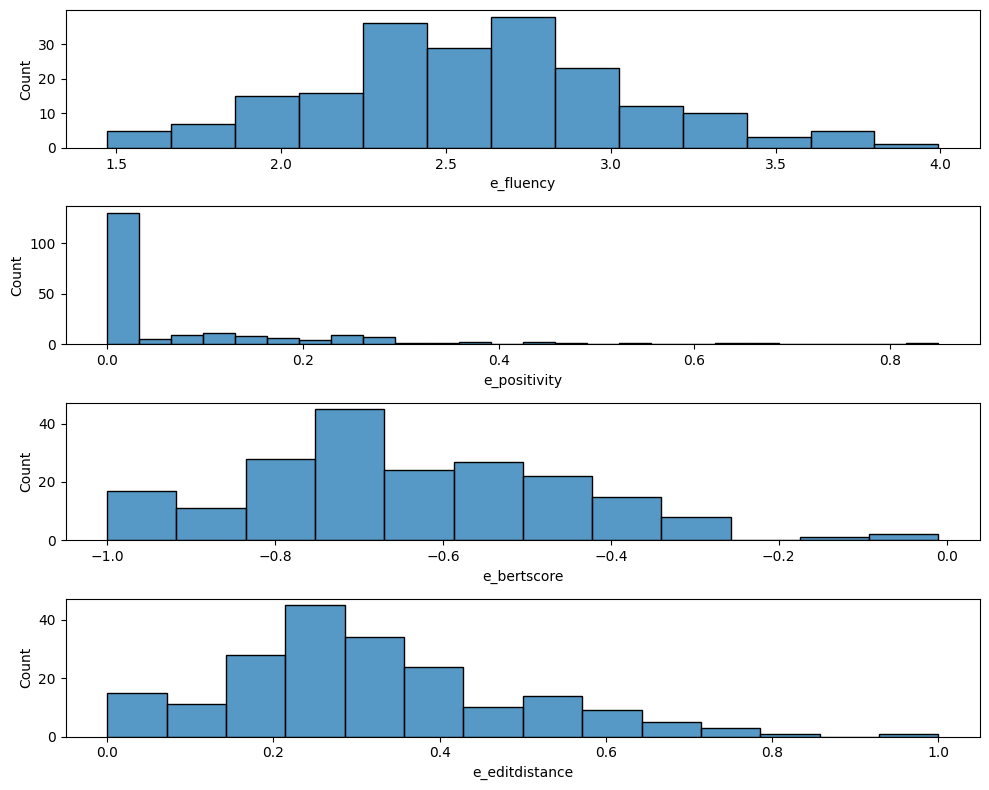

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8))
sns.histplot(data=jsons['mix_scale'], 
             x='e_fluency',
             ax=axes[0])
axes[0].set_xlabel('e_fluency')

sns.histplot(data=jsons['mix_scale'], 
             x='e_positivity',
             ax=axes[1])
axes[1].set_xlabel('e_positivity')

sns.histplot(data=jsons['mix_scale'], 
             x='e_bertscore',
             ax=axes[2])
axes[2].set_xlabel('e_bertscore')

sns.histplot(data=jsons['mix_scale'], 
             x='e_editdistance',
             ax=axes[3])
axes[3].set_xlabel('e_editdistance')

plt.tight_layout()

In [11]:
jsons['log_scale'][['loss_0', 'loss_1', 'loss_2', 'loss_3']].describe()

,loss_0,loss_1,loss_2,loss_3
count,200.000000,200.000000,1.990000e+02,200.000000
mean,2.619297,0.093969,4.535393e-01,-3.419490
std,0.475507,0.141806,3.331674e-01,6.570537
min,1.504883,0.000299,-7.152555e-07,-23.025850
25%,2.324219,0.020830,2.380080e-01,-1.734039
50%,2.613281,0.028159,3.949154e-01,-1.303983
75%,2.911621,0.116602,6.317068e-01,-0.906085
max,4.136719,0.879947,2.195910e+00,-0.087011


In [12]:
jsons['proba_scale'][['loss_0', 'loss_1', 'loss_2', 'loss_3']].describe()

,loss_0,loss_1,loss_2,loss_3
count,200.000000,200.000000,200.000000,200.000000
mean,-0.043718,-0.973840,-0.593804,0.349670
std,0.030395,0.065204,0.157622,0.138492
min,-0.192852,-0.999842,-0.934691,0.083333
25%,-0.058177,-0.995281,-0.713387,0.250000
50%,-0.039317,-0.988301,-0.607874,0.333333
75%,-0.021823,-0.974963,-0.502311,0.428289
max,-0.000888,-0.301729,-0.053023,0.750000
